<a href="https://colab.research.google.com/github/Sharu-052897/deep-learning/blob/main/TL%26EMO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

Training images: (50000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)


In [ ]:
train_mask = (y_train.flatten() == 3) | (y_train.flatten() == 5)
test_mask = (y_test.flatten() == 3) | (y_test.flatten() == 5)

X_train = X_train[train_mask]
y_train = y_train[train_mask]

X_test = X_test[test_mask]
y_test = y_test[test_mask]

In [ ]:
y_train = (y_train.flatten() == 5).astype(int)
y_test = (y_test.flatten() == 5).astype(int)

print("Cat = 0")
print("Dog = 1")

Cat = 0
Dog = 1


In [ ]:
X_train, _, y_train, _ = train_test_split(
    X_train,
    y_train,
    train_size=4000,
    random_state=42,
    stratify=y_train
)

X_test, _, y_test, _ = train_test_split(
    X_test,
    y_test,
    train_size=1000,
    random_state=42,
    stratify=y_test
)

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

Training images: (4000, 32, 32, 3)
Testing images: (1000, 32, 32, 3)


In [ ]:
X_train = tf.image.resize(X_train, (96, 96)).numpy()
X_test = tf.image.resize(X_test, (96, 96)).numpy()

print(X_train.shape)

(4000, 96, 96, 3)


In [ ]:
custom_cnn = keras.Sequential([

    layers.Input(shape=(96, 96, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

In [ ]:
custom_cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_cnn = custom_cnn.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 65s 639ms/step - accuracy: 0.5184 - loss: 0.6938 - val_accuracy: 0.5562 - val_loss: 0.6875
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 63s 624ms/step - accuracy: 0.5809 - loss: 0.6720 - val_accuracy: 0.5888 - val_loss: 0.6603
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 53s 528ms/step - accuracy: 0.6009 - loss: 0.6596 - val_accuracy: 0.6175 - val_loss: 0.6515
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 84s 547ms/step - accuracy: 0.6322 - loss: 0.6444 - val_accuracy: 0.6112 - val_loss: 0.6382
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 80s 531ms/step - accuracy: 0.6503 - loss: 0.6174 - val_accuracy: 0.6587 - val_loss: 0.6180


In [ ]:
cnn_loss, cnn_accuracy = custom_cnn.evaluate(
    X_test,
    y_test
)

print("Custom CNN Accuracy:", cnn_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.6490 - loss: 0.6236
Custom CNN Accuracy: 0.6489999890327454


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [ ]:
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

In [ ]:
resnet_base.trainable = False

In [ ]:
resnet_model = keras.Sequential([

    resnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

In [ ]:
resnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
X_train_resnet = preprocess_input(X_train.copy())
X_test_resnet = preprocess_input(X_test.copy())

In [ ]:
history_resnet = resnet_model.fit(
    X_train_resnet,
    y_train,
    epochs=5,
    batch_size=10,
    validation_split=0.2
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.7959 - loss: 0.5004 - val_accuracy: 0.8550 - val_loss: 0.3363
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.8650 - loss: 0.3172 - val_accuracy: 0.8525 - val_loss: 0.3279
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.8856 - loss: 0.2713 - val_accuracy: 0.8625 - val_loss: 0.3449
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.8984 - loss: 0.2335 - val_accuracy: 0.8575 - val_loss: 0.3569
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9119 - loss: 0.2114 - val_accuracy: 0.8587 - val_loss: 0.3511


In [ ]:
resnet_loss, resnet_accuracy = resnet_model.evaluate(
    X_test_resnet,
    y_test
)

print("ResNet50 Accuracy:", resnet_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 876ms/step - accuracy: 0.8510 - loss: 0.3499
ResNet50 Accuracy: 0.8510000109672546


In [ ]:
resnet_base.trainable = True

for layer in resnet_base.layers[:-20]:
    layer.trainable = False

In [ ]:
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_finetune = resnet_model.fit(
    X_train_resnet,
    y_train,
    epochs=3,
    batch_size=10,
    validation_split=0.2
)

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.9141 - loss: 0.2232 - val_accuracy: 0.8612 - val_loss: 0.3326
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.9397 - loss: 0.1742 - val_accuracy: 0.8625 - val_loss: 0.3312
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.9506 - loss: 0.1456 - val_accuracy: 0.8687 - val_loss: 0.3292


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

In [ ]:
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

In [ ]:
vgg_base.trainable = False

In [ ]:
vgg_model = keras.Sequential([

    vgg_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

In [ ]:
vgg_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
X_train_vgg = preprocess_input(X_train.copy())
X_test_vgg = preprocess_input(X_test.copy())

In [ ]:
history_vgg = vgg_model.fit(
    X_train_vgg,
    y_train,
    epochs=5,
    batch_size=10,
    validation_split=0.2
)

Epoch 1/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 393s 1s/step - accuracy: 0.7487 - loss: 0.9613 - val_accuracy: 0.8062 - val_loss: 0.4299
Epoch 2/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 436s 1s/step - accuracy: 0.8284 - loss: 0.4065 - val_accuracy: 0.8000 - val_loss: 0.4245
Epoch 3/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 387s 1s/step - accuracy: 0.8525 - loss: 0.3349 - val_accuracy: 0.8125 - val_loss: 0.3981
Epoch 4/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 387s 1s/step - accuracy: 0.8753 - loss: 0.2843 - val_accuracy: 0.8288 - val_loss: 0.4079
Epoch 5/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 386s 1s/step - accuracy: 0.8931 - loss: 0.2463 - val_accuracy: 0.8438 - val_loss: 0.3984


In [ ]:
vgg_loss, vgg_accuracy = vgg_model.evaluate(
    X_test_vgg,
    y_test
)

print("VGG16 Accuracy:", vgg_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.8390 - loss: 0.3985
VGG16 Accuracy: 0.8389999866485596


In [ ]:
cnn_predictions = custom_cnn.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step


In [ ]:
resnet_predictions = resnet_model.predict(
    X_test_resnet
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 986ms/step


In [ ]:
vgg_predictions = vgg_model.predict(
    X_test_vgg
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step


In [ ]:
ensemble_predictions = (
    cnn_predictions +
    resnet_predictions +
    vgg_predictions
) / 3

In [ ]:
ensemble_classes = (
    ensemble_predictions >= 0.5
).astype(int).flatten()

In [ ]:
ensemble_accuracy = np.mean(
    ensemble_classes == y_test
)

print("Ensemble Accuracy:", ensemble_accuracy)

Ensemble Accuracy: 0.865


In [ ]:
print("Custom CNN Accuracy :", cnn_accuracy)
print("ResNet50 Accuracy   :", resnet_accuracy)
print("VGG16 Accuracy      :", vgg_accuracy)
print("Ensemble Accuracy   :", ensemble_accuracy)

Custom CNN Accuracy : 0.6489999890327454
ResNet50 Accuracy   : 0.8510000109672546
VGG16 Accuracy      : 0.8389999866485596
Ensemble Accuracy   : 0.865


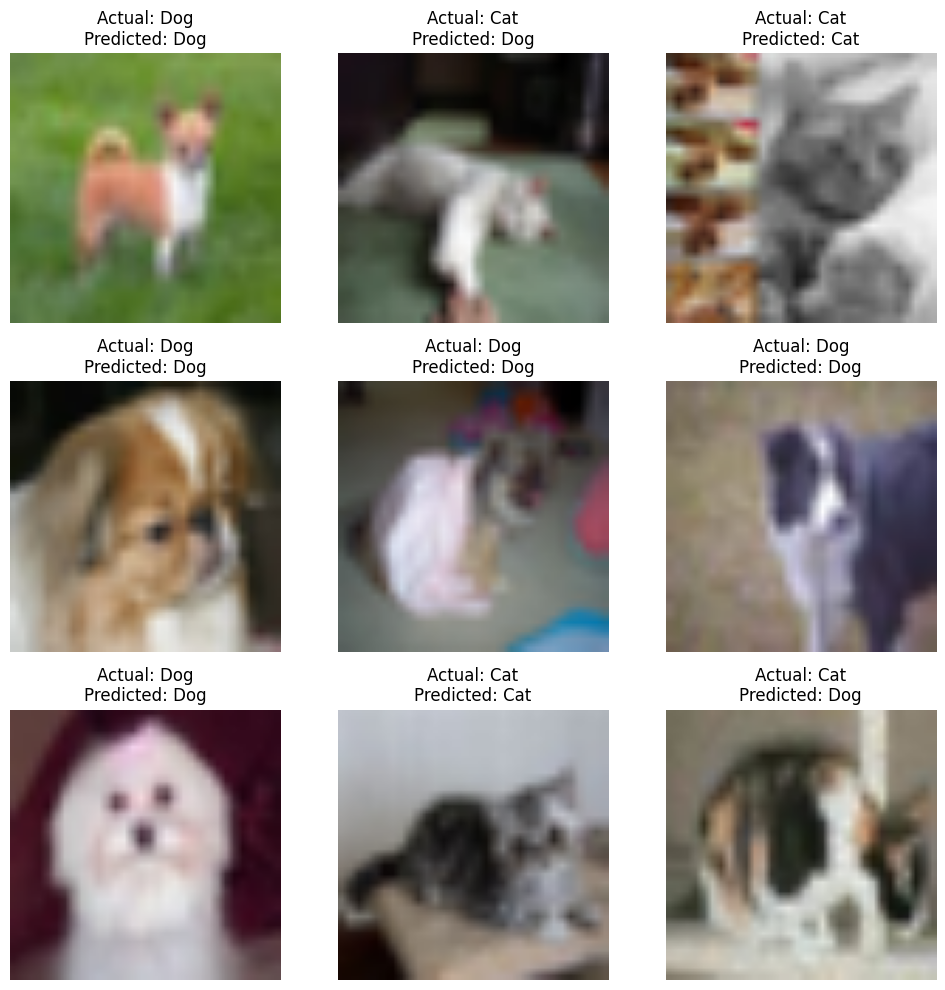

In [ ]:
plt.figure(figsize=(10, 10))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(X_test[i].astype("uint8"))

    actual = "Dog" if y_test[i] == 1 else "Cat"

    predicted = (
        "Dog"
        if ensemble_classes[i] == 1
        else "Cat"
    )

    plt.title(
        "Actual: " + actual +
        "\nPredicted: " + predicted
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

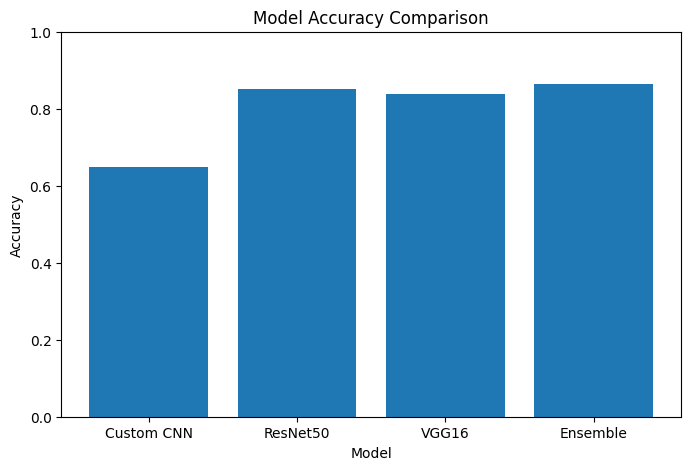

In [ ]:
models = [
    "Custom CNN",
    "ResNet50",
    "VGG16",
    "Ensemble"
]

accuracies = [
    cnn_accuracy,
    resnet_accuracy,
    vgg_accuracy,
    ensemble_accuracy
]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 1)

plt.show()